# Ablation 02 — k (Sparsity) Sweep with Null-Calibrated Jaccard

Sweep `k ∈ {8, 16, 32, 64}` at fixed `dict_size=2048` (LR auto-scales from `dict_size` only, so constant across groups). 4 seeds (0, 42, 123, 456), 12000 steps each.

For each k-group: within-group reconstruction (cosine, VE, MSE, L0, dead%), within-group index-Jaccard (`compute_stability`, `n=K`), exact hypergeometric null, signal-to-null ratio with bootstrap 95% CI, and consensus reappearance (co-primary).

The baseline (dict_size=4096, k=32) is a standalone null-calibrated anchor — never compared via Jaccard (different `dict_size`).

**Protocol.** Within-group Jaccard only (never across configs); per-group `a4` output dirs; test embeddings only; safe deserialization via `SAEManager.load`.

## 0. Setup & Configuration

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("PYTHONHASHSEED", "0")

import sys
import json
import math
from pathlib import Path

import numpy as np
import torch

# Walk up to find project root (has 'src/').
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import torch
DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

print(f'Project root: {PROJECT_ROOT}')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {DEVICE}')

Project root: /Users/marcantoniolopez/Documents/github/xai-project-5
PyTorch: 2.12.0
Device: mps


In [2]:
import config

# Output-dir isolation: override mutable PathsConfig in place to per-group a2 dirs.
ABLATION_ROOT = "ablation_a2"
MODELS_A2     = config.paths.models_dir / ABLATION_ROOT
RESULTS_A2    = config.paths.results_dir / "ablation"

# Unified figures dir across all ablation notebooks.
FIGURES_DIR   = PROJECT_ROOT / "results" / "figures" / "ablation"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_A2    = FIGURES_DIR
for d in (MODELS_A2, RESULTS_A2, FIGURES_A2):
    d.mkdir(parents=True, exist_ok=True)

# Committed splits (NOT rebuilt).
TRAIN_EMB = config.paths.train_embeddings_path
TEST_EMB  = config.paths.test_embeddings_path

# dict_size fixed -> LR auto-scale is constant across k-groups.
DICT_SIZE     = 2048
K_GRID        = (8, 16, 32, 64)
ABLATION_SEEDS = (0, 42, 123, 456)
N_STEPS       = 12_000
BATCH_SIZE    = config.sae.batch_size
ACTIVATION_DIM = config.sae.activation_dim

print('=== Ablation 02 — k sweep (dict_size FIXED) ===')
print(f'dict_size      = {DICT_SIZE}  (FIXED across all k-groups)')
print(f'k grid         = {K_GRID}')
print(f'seeds          = {ABLATION_SEEDS}  (primary for naming: 42)')
print(f'steps / batch  = {N_STEPS} / {BATCH_SIZE}')
print(f'lr             = auto (~{2e-4 / math.sqrt(DICT_SIZE/16384):.1e}; constant across groups)')
print(f'models dir     = {MODELS_A2}')
print(f'results dir    = {RESULTS_A2}')
print(f'figures dir    = {FIGURES_A2}')

=== Ablation 02 — k sweep (dict_size FIXED) ===
dict_size      = 2048  (FIXED across all k-groups)
k grid         = (8, 16, 32, 64)
seeds          = (0, 42, 123, 456)  (primary for naming: 42)
steps / batch  = 12000 / 256
lr             = auto (~5.7e-04; constant across groups)
models dir     = /Users/marcantoniolopez/Documents/github/xai-project-5/models/ablation_a2
results dir    = /Users/marcantoniolopez/Documents/github/xai-project-5/results/ablation
figures dir    = /Users/marcantoniolopez/Documents/github/xai-project-5/results/figures/ablation


In [3]:
import utils

for name, p in [('train_embeddings', TRAIN_EMB), ('test_embeddings', TEST_EMB)]:
    ok = Path(p).exists()
    t = utils.load_tensor(p) if ok else None
    print(f'  [{"OK" if ok else "MISSING"}] {name}: {t.shape if ok else p}')

test_emb = utils.load_tensor(TEST_EMB)
train_emb = utils.load_tensor(TRAIN_EMB)
N_TEST = test_emb.shape[0]
print(f'\nN_test = {N_TEST}  (used for bootstrap CI)')

/Users/marcantoniolopez/Documents/github/xai-project-5/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  [OK] train_embeddings: torch.Size([5976, 512])
  [OK] test_embeddings: torch.Size([1494, 512])

N_test = 1494  (used for bootstrap CI)


## 1. SAE Training — (k × seed) grid

`dict_size` fixed at 2048 so the auto-scaled LR is identical across k-groups. Each k-group writes to `models/ablation_a2/dict2048_k{K}/sae_seed{seed}/` to avoid leaf collisions. `train()` uses `TopKTrainer` with library defaults (`auxk_alpha=1/32`, `dead_feature_threshold=10_000_000`).

In [4]:
from autoencoder.sae_module import SAEManager

trained = {}  # trained[k] = {seed: model_dir}
for K in K_GRID:
    trained[K] = {}
    group_dir = MODELS_A2 / f'dict2048_k{K}'
    group_dir.mkdir(parents=True, exist_ok=True)
    for seed in ABLATION_SEEDS:
        ae_path = group_dir / f'sae_seed{seed}' / 'trainer_0' / 'ae.pt'
        alt     = group_dir / f'sae_seed{seed}' / 'ae.pt'
        if ae_path.exists() or alt.exists():
            print(f'[skip] k={K} seed={seed} already trained')
            trained[K][seed] = group_dir / f'sae_seed{seed}'
            continue
        print(f'\n--- Training k={K} seed={seed} (dict_size={DICT_SIZE}, {N_STEPS} steps) ---')
        mgr = SAEManager({
            'device': DEVICE,
            'activation_dim': ACTIVATION_DIM,
            'dict_size': DICT_SIZE,
            'k': K,
            'warmup_steps': config.sae.warmup_steps,
        })
        model_dir = mgr.train(
            embeddings_path=TRAIN_EMB,
            seed=seed,
            save_dir=str(group_dir),
            steps=N_STEPS,
            batch_size=BATCH_SIZE,
        )
        trained[K][seed] = model_dir
        print(f'Saved: {model_dir}')

print('\nAll groups trained. Summary:')
for K in K_GRID:
    print(f'  k={K}: {len(trained[K])} seeds')


[skip] k=8 seed=0 already trained
[skip] k=8 seed=42 already trained
[skip] k=8 seed=123 already trained
[skip] k=8 seed=456 already trained
[skip] k=16 seed=0 already trained
[skip] k=16 seed=42 already trained
[skip] k=16 seed=123 already trained
[skip] k=16 seed=456 already trained
[skip] k=32 seed=0 already trained
[skip] k=32 seed=42 already trained
[skip] k=32 seed=123 already trained
[skip] k=32 seed=456 already trained
[skip] k=64 seed=0 already trained
[skip] k=64 seed=42 already trained
[skip] k=64 seed=123 already trained
[skip] k=64 seed=456 already trained

All groups trained. Summary:
  k=8: 4 seeds
  k=16: 4 seeds
  k=32: 4 seeds
  k=64: 4 seeds


## 2. Per-group reconstruction metrics

Per k-group (4 seeds, **test** embeddings): cosine, MSE, variance-explained (`1 − mse/var(x)`), L0 (should equal `k`), dead% (features never nonzero over test).

In [5]:
def variance_explained(mgr, x):
    """1 - MSE / Var(x), variance computed over the flattened test tensor."""
    with torch.no_grad():
        x_hat = mgr._ae(x.to(mgr._device))
    mse = ((x_hat - x.to(mgr._device)) ** 2).mean().item()
    var = x.to(mgr._device).var().item()
    return 1.0 - mse / var, mse

per_k_metrics = {}
test_var = test_emb.var().item()
print(f'Test-embedding variance (denominator for VE): {test_var:.6f}\n')

for K in K_GRID:
    cosines, mses, ves, l0s, deads = [], [], [], [], []
    for seed in ABLATION_SEEDS:
        mgr = SAEManager({'device': DEVICE, 'dict_size': DICT_SIZE, 'k': K})
        mgr.load(trained[K][seed])
        cos = mgr.compute_cosine_reconstruction(test_emb)
        mse = mgr.compute_reconstruction_mse(test_emb)
        ve = 1.0 - mse / test_var
        sp = mgr.compute_sparsity_metrics(test_emb)
        cosines.append(cos); mses.append(mse); ves.append(ve)
        l0s.append(sp['l0_mean']); deads.append(sp['dead_features_pct'])
        del mgr._ae; mgr._ae = None
        try:
            torch.cuda.empty_cache()
        except Exception:
            pass
    per_k_metrics[K] = {
        'cosine': float(np.mean(cosines)),
        'mse': float(np.mean(mses)),
        'var_explained': float(np.mean(ves)),
        'l0_mean': float(np.mean(l0s)),
        'dead_pct': float(np.mean(deads)),
    }
    print(f'k={K:>2}: cosine={np.mean(cosines):.4f}  VE={np.mean(ves):.4f}  '
          f'MSE={np.mean(mses):.2e}  L0={np.mean(l0s):.1f} (expect {K})  dead%={np.mean(deads):.1f}')


Test-embedding variance (denominator for VE): 0.001953



k= 8: cosine=0.9836  VE=0.9674  MSE=6.37e-05  L0=8.0 (expect 8)  dead%=91.3


k=16: cosine=0.9887  VE=0.9775  MSE=4.39e-05  L0=16.0 (expect 16)  dead%=74.6


k=32: cosine=0.9924  VE=0.9848  MSE=2.98e-05  L0=32.0 (expect 32)  dead%=41.6


k=64: cosine=0.9972  VE=0.9943  MSE=1.11e-05  L0=64.0 (expect 64)  dead%=40.6


## 3. Within-group index-Jaccard + exact hypergeometric null

For each k-group, `compute_stability` over that group's 4 seeds only, with `config={'dict_size':2048,'k':K}` and `n=K` passed explicitly.

For two independent size-`k` subsets of a `D`-set, intersection size `j` ~ `Hypergeom(D, k, k)`. Under the mean-of-ratios convention matching `compute_stability`:

`null(k, D) = Σ_{j=0}^{k} [ j / (2k − j) ] · P(j)`,   `P(j) = C(k,j)·C(D−k, k−j) / C(D,k)`

implemented via `scipy.stats.hypergeom`.

In [6]:
from scipy.stats import hypergeom
from math import comb

def exact_null_jaccard(k, D):
    """E[per-sample index-Jaccard] for two independent size-k subsets of a D-set
    (mean-of-ratios convention matching compute_stability)."""
    total = 0.0
    for j in range(0, k + 1):
        p_j = hypergeom.pmf(j, D, k, k)
        if p_j <= 0:
            continue
        jac_j = j / (2 * k - j) if (2 * k - j) > 0 else 0.0
        total += jac_j * p_j
    return total

# Sanity: null(1,2) = 0.5.
assert abs(exact_null_jaccard(1, 2) - 0.5) < 1e-9
# k=2, D=4: enumerate to confirm.
_enum = 0.0
for a in range(4):
    for b in range(4):
        A = {a}; pass
print('hypergeom sanity: null(1,2) =', exact_null_jaccard(1, 2), '(expect 0.5)')

nulls = {K: exact_null_jaccard(K, DICT_SIZE) for K in K_GRID}
# Baseline anchor null (dict_size=4096, k=32) — computed, not via within-group Jaccard.
BASE_NULL = exact_null_jaccard(32, 4096)
BASE_RAW  = 0.0038  # committed baseline cross-seed mean index-Jaccard

print('\nExact hypergeometric nulls (per-sample-averaged convention):')
for K in K_GRID:
    print(f'  null(k={K:>2}, D={DICT_SIZE}) = {nulls[K]:.6f}')
print(f'  BASELINE null(k=32, D=4096) = {BASE_NULL:.6f}  (raw 0.0038 -> ratio {BASE_RAW/BASE_NULL:.3f})')

hypergeom sanity: null(1,2) = 0.5 (expect 0.5)

Exact hypergeometric nulls (per-sample-averaged convention):
  null(k= 8, D=2048) = 0.002087
  null(k=16, D=2048) = 0.004047
  null(k=32, D=2048) = 0.007997
  null(k=64, D=2048) = 0.015994
  BASELINE null(k=32, D=4096) = 0.003983  (raw 0.0038 -> ratio 0.954)


In [7]:
# Within-group Jaccard per k-group (own 4 seeds ONLY).
within_group = {}
for K in K_GRID:
    model_dirs = [str(trained[K][s]) for s in ABLATION_SEEDS]
    print(f'\nk={K}: compute_stability over {len(model_dirs)} seeds, n={K}')
    stab = SAEManager.compute_stability(
        model_dirs, test_emb,
        config={'device': DEVICE, 'dict_size': DICT_SIZE, 'k': K},
        n=K,
    )
    within_group[K] = stab
    print(f'  mean Jaccard = {stab["mean_jaccard"]:.6f}   '
          f'(null = {nulls[K]:.6f}, ratio = {stab["mean_jaccard"]/nulls[K]:.3f})')



k=8: compute_stability over 4 seeds, n=8
  mean Jaccard = 0.002487   (null = 0.002087, ratio = 1.192)

k=16: compute_stability over 4 seeds, n=16


  mean Jaccard = 0.004752   (null = 0.004047, ratio = 1.174)

k=32: compute_stability over 4 seeds, n=32


  mean Jaccard = 0.007751   (null = 0.007997, ratio = 0.969)

k=64: compute_stability over 4 seeds, n=64


  mean Jaccard = 0.016572   (null = 0.015994, ratio = 1.036)


### 3.1 Per-sample Jaccard bootstrap → signal-to-null ratio 95% CI

Recompute per-sample Jaccard for every seed pair from raw top-`k` index sets, resample the 1494 test indices 1000×, take 2.5/97.5 percentiles of `mean_ratio = mean_over_pairs[per-sample Jaccard] / null(k, D)`.

In [8]:
def per_sample_jaccard_for_group(K, n_samples=N_TEST):
    """Return (n_seeds, n_seeds, n_samples) upper-triangular-mean-per-sample array
    of per-sample Jaccard (mean over the C(n_seeds,2) seed pairs, per sample)."""
    n_seeds = len(ABLATION_SEEDS)
    # Top-k index sets per seed per sample.
    sets = []
    for seed in ABLATION_SEEDS:
        mgr = SAEManager({'device': DEVICE, 'dict_size': DICT_SIZE, 'k': K})
        mgr.load(trained[K][seed])
        per_s = []
        # chunk to avoid OOM
        for i in range(0, n_samples, 512):
            chunk = test_emb[i:i+512].to(DEVICE)
            _, _, idx = mgr.encode_topk(chunk)   # (B, K) unsorted indices
            per_s.extend([set(row.tolist()) for row in idx.cpu()])
        sets.append(per_s)
        del mgr._ae; mgr._ae = None
        try: torch.cuda.empty_cache()
        except Exception: pass
    # per-sample mean Jaccard averaged over all seed pairs.
    pair_means = np.zeros(n_samples)
    n_pairs = 0
    for a in range(n_seeds):
        for b in range(a + 1, n_seeds):
            for s in range(n_samples):
                u = sets[a][s] | sets[b][s]
                inter = len(sets[a][s] & sets[b][s])
                pair_means[s] += inter / len(u) if u else 0.0
            n_pairs += 1
    pair_means /= n_pairs
    return pair_means

rng = np.random.default_rng(0)
boot = {}
for K in K_GRID:
    ps = per_sample_jaccard_for_group(K)            # (N_TEST,) per-sample mean Jaccard
    ratios = ps / nulls[K]                           # per-sample signal-to-null ratio
    # bootstrap over test samples
    samp = np.empty(1000)
    idx_all = np.arange(N_TEST)
    for b in range(1000):
        bs = rng.choice(idx_all, size=N_TEST, replace=True)
        samp[b] = ratios[bs].mean()
    lo, hi = np.percentile(samp, [2.5, 97.5])
    raw = within_group[K]['mean_jaccard']
    boot[K] = {
        'raw_jaccard': float(raw),
        'exact_null': float(nulls[K]),
        'signal_to_null': float(raw / nulls[K]),
        'ci_low': float(lo),
        'ci_high': float(hi),
        'excludes_one': bool(lo > 1.0),
    }
    print(f'k={K:>2}: raw={raw:.5f}  null={nulls[K]:.5f}  ratio={raw/nulls[K]:.3f}  '
          f'95% CI [{lo:.3f}, {hi:.3f}]  excludes 1? {lo > 1.0}')


k= 8: raw=0.00249  null=0.00209  ratio=1.192  95% CI [1.071, 1.309]  excludes 1? True


k=16: raw=0.00475  null=0.00405  ratio=1.174  95% CI [1.114, 1.236]  excludes 1? True


k=32: raw=0.00775  null=0.00800  ratio=0.969  95% CI [0.940, 0.998]  excludes 1? False


k=64: raw=0.01657  null=0.01599  ratio=1.036  95% CI [1.024, 1.048]  excludes 1? True


### 3.2 Co-primary: consensus reappearance (connected_components, mirrors a0)

Within each k-group, pool LIVE decoder rows across the 4 seeds (drop norm `< 1e-8`), L2-normalize, build sparse `cosine > 0.90` adjacency, run `scipy.sparse.csgraph.connected_components`. `consensus_rate(K, min_seeds)` is the fraction of pooled LIVE rows in a cluster spanning `>= min_seeds` seeds. Same algorithm as a0/a1/a4 for comparability.

In [9]:
def consensus_rate(K, min_seeds=2):
    """Connected-components consensus on pooled LIVE decoder rows (matches a0)."""
    DEAD_THRESHOLD = 1e-8
    TAU = 0.90  # cosine boundary, STRICT (> tau)
    import torch.nn.functional as F
    from scipy import sparse
    from scipy.sparse.csgraph import connected_components

    rows_list, seed_labels = [], []
    for seed in ABLATION_SEEDS:
        mgr = SAEManager({'device': DEVICE, 'activation_dim': ACTIVATION_DIM,
                          'dict_size': DICT_SIZE, 'k': K})
        mgr.load(trained[K][seed])
        W = mgr.get_decoder_weights().cpu()        # (dict_size, 512)
        norms = W.norm(dim=1)
        live = (norms >= DEAD_THRESHOLD).nonzero(as_tuple=True)[0]
        rows_list.append(W[live].clone())
        seed_labels.append(np.full(len(live), seed, dtype=np.int64))
        del mgr._ae; mgr._ae = None
        try: torch.cuda.empty_cache()
        except Exception: pass
    rows_n = F.normalize(torch.cat(rows_list, dim=0).float(), dim=1) \
                 .numpy().astype(np.float64)
    labels = np.concatenate(seed_labels)

    cos_full = rows_n @ rows_n.T
    np.fill_diagonal(cos_full, -1.0)
    adj = sparse.csr_matrix(cos_full > TAU)              # STRICT > tau
    n_components, cluster_labels = connected_components(csgraph=adj, directed=False)

    # per-row count of distinct seeds in its cluster (a0's consensus_rate(m))
    row_seedcount = np.empty(len(labels), dtype=np.int64)
    for c in range(n_components):
        member_seeds = np.unique(labels[cluster_labels == c])
        row_seedcount[cluster_labels == c] = len(member_seeds)
    return float((row_seedcount >= min_seeds).mean())

consensus = {}
for K in K_GRID:
    consensus[K] = {
        'consensus_rate_ge2': consensus_rate(K, min_seeds=2),
        'consensus_rate_ge3': consensus_rate(K, min_seeds=3),
    }
    print(f'k={K:>2}: consensus reappearance (connected_components, cos>0.90)  '
          f'>=2 seeds: {consensus[K]["consensus_rate_ge2"]:.3f}  '
          f'>=3 seeds: {consensus[K]["consensus_rate_ge3"]:.3f}')

k= 8: consensus reappearance (connected_components, cos>0.90)  >=2 seeds: 0.006  >=3 seeds: 0.005


k=16: consensus reappearance (connected_components, cos>0.90)  >=2 seeds: 0.001  >=3 seeds: 0.001


k=32: consensus reappearance (connected_components, cos>0.90)  >=2 seeds: 0.000  >=3 seeds: 0.000


k=64: consensus reappearance (connected_components, cos>0.90)  >=2 seeds: 0.000  >=3 seeds: 0.000


## 4. Figures

**(1) k-vs-stability:** raw within-group Jaccard vs exact null, secondary axis = signal-to-null ratio with bootstrap CI, baseline anchor marked.

**(2) Pareto front:** variance-explained vs signal-to-null, one point per k, baseline anchor marked.

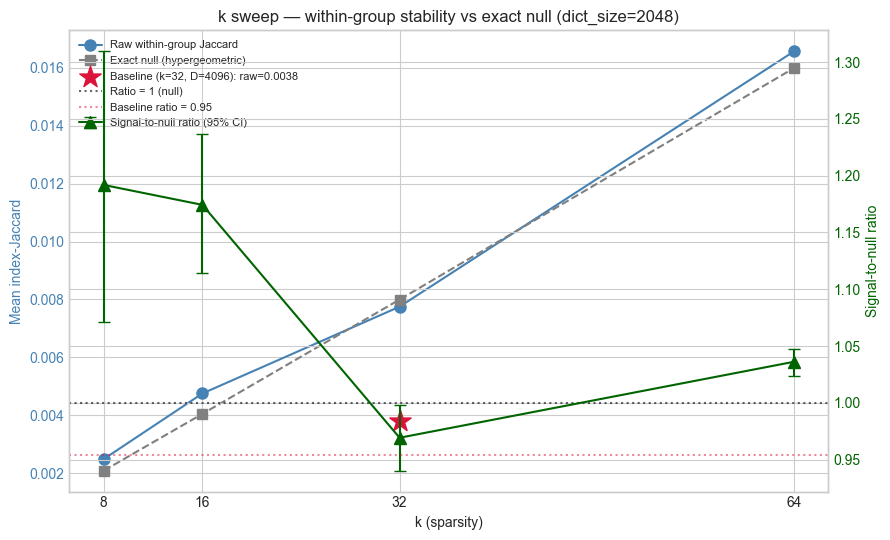

Saved: /Users/marcantoniolopez/Documents/github/xai-project-5/results/figures/ablation/a2_k_vs_stability.png


In [10]:
import matplotlib
matplotlib.use('Agg')  # safe in headless; remove for inline
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

ks = list(K_GRID)
raws  = [boot[K]['raw_jaccard'] for K in ks]
nulls_line = [nulls[K] for K in ks]
ratios = [boot[K]['signal_to_null'] for K in ks]
ci_lo  = [boot[K]['ci_low'] for K in ks]
ci_hi  = [boot[K]['ci_high'] for K in ks]
err_lo = [r - lo for r, lo in zip(ratios, ci_lo)]
err_hi = [hi - r for hi, r in zip(ci_hi, ratios)]

# Figure 1: k vs stability (dual axis)
fig, ax1 = plt.subplots(figsize=(9, 5.5))
ax1.plot(ks, raws, 'o-', color='steelblue', label='Raw within-group Jaccard', markersize=8)
ax1.plot(ks, nulls_line, 's--', color='gray', label='Exact null (hypergeometric)', markersize=7)
ax1.scatter([32], [BASE_RAW], marker='*', s=260, color='crimson', zorder=5,
            label=f'Baseline (k=32, D=4096): raw={BASE_RAW:.4f}')
ax1.set_xlabel('k (sparsity)')
ax1.set_ylabel('Mean index-Jaccard', color='steelblue')
ax1.set_xticks(ks)
ax1.set_title('k sweep — within-group stability vs exact null (dict_size=2048)')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.errorbar(ks, ratios, yerr=[err_lo, err_hi], fmt='^-', color='darkgreen',
             label='Signal-to-null ratio (95% CI)', markersize=8, capsize=4)
ax2.axhline(1.0, color='black', linestyle=':', alpha=0.6, label='Ratio = 1 (null)')
ax2.axhline(BASE_RAW / BASE_NULL, color='crimson', linestyle=':', alpha=0.5,
            label=f'Baseline ratio = {BASE_RAW/BASE_NULL:.2f}')
ax2.set_ylabel('Signal-to-null ratio', color='darkgreen')
ax2.tick_params(axis='y', labelcolor='darkgreen')

lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lab1 + lab2, loc='upper left', fontsize=8)
plt.tight_layout()
f1 = FIGURES_A2 / 'a2_k_vs_stability.png'
plt.savefig(f1, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {f1}')

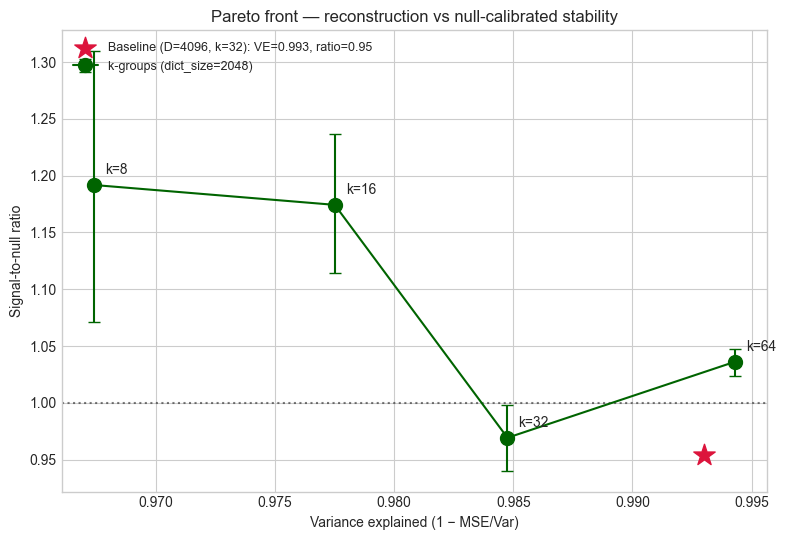

Saved: /Users/marcantoniolopez/Documents/github/xai-project-5/results/figures/ablation/a2_pareto_front.png


In [11]:
# Figure 2: Pareto front (variance-explained vs signal-to-null)
ves = [per_k_metrics[K]['var_explained'] for K in ks]

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.errorbar(ves, ratios, xerr=None, yerr=[err_lo, err_hi], fmt='o-', color='darkgreen',
            markersize=10, capsize=4, label='k-groups (dict_size=2048)')
for K, x, y in zip(ks, ves, ratios):
    ax.annotate(f'k={K}', (x, y), textcoords='offset points', xytext=(8, 8), fontsize=10)
ax.scatter([0.993], [BASE_RAW / BASE_NULL], marker='*', s=260, color='crimson', zorder=5,
           label=f'Baseline (D=4096, k=32): VE=0.993, ratio={BASE_RAW/BASE_NULL:.2f}')
ax.axhline(1.0, color='black', linestyle=':', alpha=0.5)
ax.set_xlabel('Variance explained (1 − MSE/Var)')
ax.set_ylabel('Signal-to-null ratio')
ax.set_title('Pareto front — reconstruction vs null-calibrated stability')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
f2 = FIGURES_A2 / 'a2_pareto_front.png'
plt.savefig(f2, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {f2}')

## 5. Save results

Write `results/ablation/a2_k_sweep.json` with per-k metrics, null calibration, baseline anchor, and hypothesis verdict.

In [12]:
results = {
    'ablation': '02_k_sweep',
    'protocol': {
        'dict_size_fixed': DICT_SIZE,
        'k_grid': list(K_GRID),
        'seeds': list(ABLATION_SEEDS),
        'steps': N_STEPS,
        'lr': 'auto (constant across groups; scales with dict_size only)',
        'n_test': N_TEST,
        'jaccard': 'within-group only; compute_stability n=k passed explicitly',
        'null': 'exact hypergeometric, mean-of-ratios convention',
        'ci': 'bootstrap 1000x over test samples',
    },
    'per_k': {},
    'baseline_anchor': {
        'dict_size': 4096, 'k': 32,
        'raw_jaccard': BASE_RAW,
        'exact_null': float(BASE_NULL),
        'signal_to_null': float(BASE_RAW / BASE_NULL),
        'note': 'standalone null-calibrated point; NOT compared via Jaccard (different dict_size)',
    },
}

for K in K_GRID:
    results['per_k'][str(K)] = {
        **boot[K],
        **consensus[K],
        **per_k_metrics[K],
    }

out_path = RESULTS_A2 / 'a2_k_sweep.json'
with open(out_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f'Saved: {out_path}')

# Hypothesis verdict table
print('\n=== Signal-to-null ratio summary ===')
print(f"{'k':>4} {'raw':>10} {'null':>10} {'ratio':>8} {'95% CI':>20} {'excl1':>6} {'VE':>7} {'dead%':>7}")
for K in K_GRID:
    b = boot[K]
    print(f"{K:>4} {b['raw_jaccard']:>10.5f} {b['exact_null']:>10.5f} "
          f"{b['signal_to_null']:>8.3f} [{b['ci_low']:.3f}, {b['ci_high']:.3f}]"
          f"{'':<2}{str(b['excludes_one']):>6} "
          f"{per_k_metrics[K]['var_explained']:>7.4f} {per_k_metrics[K]['dead_pct']:>7.1f}")
print(f"\nBaseline anchor: ratio = {BASE_RAW/BASE_NULL:.3f} (raw {BASE_RAW}, null {BASE_NULL:.5f})")


Saved: /Users/marcantoniolopez/Documents/github/xai-project-5/results/ablation/a2_k_sweep.json

=== Signal-to-null ratio summary ===
   k        raw       null    ratio               95% CI  excl1      VE   dead%
   8    0.00249    0.00209    1.192 [1.071, 1.309]    True  0.9674    91.3
  16    0.00475    0.00405    1.174 [1.114, 1.236]    True  0.9775    74.6
  32    0.00775    0.00800    0.969 [0.940, 0.998]   False  0.9848    41.6
  64    0.01657    0.01599    1.036 [1.024, 1.048]    True  0.9943    40.6

Baseline anchor: ratio = 0.954 (raw 0.0038, null 0.00398)


## 6. Interpretation

- Baseline anchor ratio ~1 means raw cross-seed Jaccard is indistinguishable from random overlap.
- Rising ratio at smaller k: chance overlap shrinks faster than real overlap, so relative signal grows.
- Pareto front: best-k maximizes signal-to-null without collapsing VE.
- Dead% rises at small k (fewer features fire per pass).
- Consensus reappearance is the index-agnostic corroboration.